# Identifying Dangerous Work Tasks in OSHA Accident Narratives with TaskMatch

**Purpose:** This notebook demonstrates how [JAAT](https://github.com/Job-Ad-Research-at-QSB-LUC/JAAT)'s `TaskMatch` module can extract standardized O\*NET work tasks from unstructured text — not just job postings, but any text that describes work activities.

**How it works:** `TaskMatch` is a two-step model. Input text is first evaluated for whether it contains a task statement based on an efficient, fine-tuned BERT model [`task-classifier-mini-improved2`](https://huggingface.co/loyoladatamining/task-classifier-mini-improved2) included in JAAT.  Second, all task sentences are transformed via [`gte-small`](https://huggingface.co/thenlper/gte-small) into sentence embeddings, and cosine similarity scores compared the semantic similarity of input text against ~20,000 O\*NET labeled task descriptions that have been augmented with job postings sentences.

**Key insight:** Because semantic similarity relies on meaning, rather than keywords, `TaskMatch` retrieves O*NET labels from any text where work tasks are described — for example, workplace accident narratives.

**Data:** We use a sample of 1,000 OSHA workplace accident investigation abstracts. Each abstract describes an incident: what the worker was doing, what went wrong, and the outcome. The full dataset contains 111,000+ investigations and is available from [OSHA's public data](https://www.osha.gov/data).

**Pipeline:** Raw text → sentence splitting → TaskMatch → aggregation → visualization

## 1. Setup

In [ ]:
!pip install -q JAAT

import os
if not os.path.exists('data/accident_abstracts_sample.csv'):
    !git clone --depth 1 https://github.com/pnorlander/JAAT_Demos.git
    os.chdir('JAAT_Demos/osha_accident_taskmatch')

import pandas as pd
import matplotlib.pyplot as plt
import time
import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize
from JAAT import JAAT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.3/167.3 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 44.4 MB/s eta 0:00:00
Cloning into 'JAAT_Demos'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 163.93 KiB | 1.30 MiB/s, done.


## 2. Load Data

Each row is one OSHA accident investigation, identified by `summary_nr`. The `abstract_text` field contains the full narrative describing what happened.

In [ ]:
df = pd.read_csv('data/accident_abstracts_sample.csv')
print(f'Loaded {len(df)} accident investigations')
print(f'Average narrative length: {df["abstract_text"].str.len().mean():.0f} characters')
df.head(3)

Loaded 1000 accident investigations
Average narrative length: 503 characters


,summary_nr,abstract_text
0,511055,"at 10 am on may 19, 1986, employees #1 through..."
1,514885,"at about 2:10 p.m. on march 11, 1990, employee..."
2,566109,a maintenance crew of three electricians was r...


Let's look at a few examples to understand the data:

In [ ]:
for i in [0, 5, 10]:
    print(f'--- Investigation {df.iloc[i]["summary_nr"]} ---')
    print(df.iloc[i]['abstract_text'])
    print()

--- Investigation 511055 ---
at 10 am on may 19, 1986, employees #1 through #3 were using water and acetone to clean a simpson muller-mixer. the mixer contained less than 10 pounds of residue from a magnesium-tefron-fluorel-acetone mixture. they were located in the process building at a remote location. a flash fire occurred, apparently when flammable vapors were ignited by static electricity. the employee's shift had started at 7 am. at 8 am, in accordance with company policy, they began the shut-down process because of high winds and 20% humidity. at 8:30 they were ordered to stopthe batch process and clean up. there was no monitoring of flammable vapors at the process building. combustible material was used for the construction of the employee's work platform and for the walls of the process building. the employees were given no formal training on the hazards of the chemicals they were using. employee #1 died 29 days later and employee #2 died 5 days later. they were burned over 88%

## 3. Text Preprocessing: Sentence Splitting

`TaskMatch` works best on individual sentences. We split each accident narrative into sentences using NLTK's sentence tokenizer, creating one row per sentence.

Understanding and pre-processing the corpus may be necessary. Injecting periods into bulleted lists, compound sentences, and run-on sentences may improve the recall of the extraction.

In [ ]:
# Split each narrative into sentences
assert df['summary_nr'].is_unique, 'Duplicate summary_nr values found — check data'

df['sentences'] = df['abstract_text'].apply(sent_tokenize)
sentences_df = df.explode('sentences').reset_index(drop=True)
sentences_df['sentence_nr'] = sentences_df.groupby('summary_nr').cumcount() + 1
sentences_df = sentences_df[['summary_nr', 'sentence_nr', 'sentences']].copy()

print(f'{len(df)} narratives → {len(sentences_df)} sentences')
print(f'Average sentences per narrative: {len(sentences_df) / len(df):.1f}')
sentences_df.head()

1000 narratives → 5014 sentences
Average sentences per narrative: 5.0


,summary_nr,sentence_nr,sentences
0,511055,1,"at 10 am on may 19, 1986, employees #1 through..."
1,511055,2,the mixer contained less than 10 pounds of res...
2,511055,3,they were located in the process building at a...
3,511055,4,"a flash fire occurred, apparently when flammab..."
4,511055,5,the employee's shift had started at 7 am.


**Before and after** — here's one narrative split into its component sentences:

In [ ]:
example_id = df.iloc[0]['summary_nr']
print(f'Original narrative (investigation {example_id}):')
print(df.iloc[0]['abstract_text'])
print(f'\nSplit into {len(sentences_df[sentences_df["summary_nr"] == example_id])} sentences:')
for _, row in sentences_df[sentences_df['summary_nr'] == example_id].iterrows():
    print(f'  {row["sentence_nr"]}: {row["sentences"]}')

Original narrative (investigation 511055):
at 10 am on may 19, 1986, employees #1 through #3 were using water and acetone to clean a simpson muller-mixer. the mixer contained less than 10 pounds of residue from a magnesium-tefron-fluorel-acetone mixture. they were located in the process building at a remote location. a flash fire occurred, apparently when flammable vapors were ignited by static electricity. the employee's shift had started at 7 am. at 8 am, in accordance with company policy, they began the shut-down process because of high winds and 20% humidity. at 8:30 they were ordered to stopthe batch process and clean up. there was no monitoring of flammable vapors at the process building. combustible material was used for the construction of the employee's work platform and for the walls of the process building. the employees were given no formal training on the hazards of the chemicals they were using. employee #1 died 29 days later and employee #2 died 5 days later. they were b

## 4. Run TaskMatch

We initialize `TaskMatch` with a threshold of 0.80 (users select their preferred threshold -- a 0.80 threshold will have lower precision but higher recall, perfect for exploratory analysis).

We run TaskMatch on all sentences.

TaskMatch first checks whether each sentence is a task sentence, and then compares each task sentence against ~20,000 O\*NET task descriptions using sentence embeddings to find the best matching statement.

TaskMatch returns matches only above the user-selected cosine similarity threshold.

In [ ]:
# Initialize TaskMatch
task_matcher = JAAT.TaskMatch(threshold=0.80)

# Process all sentences in batches
start = time.time()
texts = sentences_df['sentences'].fillna('').tolist()
matches = task_matcher.get_tasks_batch(texts)
elapsed = time.time() - start

sentences_df['matched_tasks'] = matches
sentences_df['n_matches'] = sentences_df['matched_tasks'].apply(len)

n_with_match = (sentences_df['n_matches'] > 0).sum()
print(f'Processed {len(sentences_df)} sentences in {elapsed:.1f}s')
print(f'Sentences with at least one task match: {n_with_match} ({n_with_match/len(sentences_df)*100:.1f}%)')
print(f'Unique investigations with matches: {sentences_df[sentences_df["n_matches"] > 0]["summary_nr"].nunique()} / {len(df)}')

INIT
Preparing embeddings...


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/41 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Finished.
Processed 5014 sentences in 157.2s
Sentences with at least one task match: 892 (17.8%)
Unique investigations with matches: 531 / 1000


Let's look at some example matches to see what TaskMatch found:

In [ ]:
# Show sentences with their matched O*NET tasks
matched = sentences_df[sentences_df['n_matches'] > 0].head(10)
for _, row in matched.iterrows():
    print(f'Sentence: "{row["sentences"][:120]}..."' if len(row['sentences']) > 120 else f'Sentence: "{row["sentences"]}"')
    for task_id, task_desc in row['matched_tasks']:
        print(f'  → O*NET Task {task_id}: {task_desc}')
    print()

Sentence: "a flash fire occurred, apparently when flammable vapors were ignited by static electricity."
  → O*NET Task 10490: Ignite fuel in burners, using torches or flames.

Sentence: "combustible material was used for the construction of the employee's work platform and for the walls of the process buil..."
  → O*NET Task 14843: Furnish tools for employee use.

Sentence: "the employees were given no formal training on the hazards of the chemicals they were using."
  → O*NET Task 1545: Direct or monitor other workers producing chemical products.

Sentence: "two of the electricians were attaching the conductors to the lugs inside the box."
  → O*NET Task 23561: Lay out and connect electrical wiring between controls and equipment, according to wiring diagrams, using electrician's hand tools.

Sentence: "one of them tried to retrieve the piece and contacted an energized part within the enclosure."
  → O*NET Task 11262: Consult with engineers regarding technical problems with products.



## 5. Aggregate & Visualize: All Matched Tasks

Let's count the most frequently matched O\*NET tasks across all accident narratives.

In [ ]:
# Flatten all matched tasks into a single list
all_tasks = []
for task_list in sentences_df['matched_tasks']:
    if task_list:
        for task in task_list:
            if isinstance(task, (list, tuple)) and len(task) > 1:
                all_tasks.append((task[0], str(task[1])))

task_counts = pd.Series(all_tasks).value_counts().reset_index()
task_counts.columns = ['task', 'count']
task_counts['task_id'] = task_counts['task'].apply(lambda t: t[0])
task_counts['description'] = task_counts['task'].apply(lambda t: t[1])
task_counts = task_counts[['task_id', 'description', 'count']]

print(f'Total task matches: {len(all_tasks)}')
print(f'Unique O*NET tasks matched: {len(task_counts)}')
task_counts.head(20)

Total task matches: 895
Unique O*NET tasks matched: 508


,task_id,description,count
0,5040,Contact emergency medical personnel in case of...,52
1,2127,Perform emergency work during off-hours.,21
2,9440,Carry injured offenders or employees to safety...,20
3,2018,Clean work area and check and store equipment ...,15
4,4800,Coordinate truck dumping.,12
5,13752,"Dismantle defective machines for repair, using...",11
6,9821,Saw felled trees into lengths.,11
7,12264,"Clear machine jams, using hand tools.",10
8,23899,Operate equipment such as forklifts.,9
9,20653,Hammer out dents and bends in frames and weld ...,8


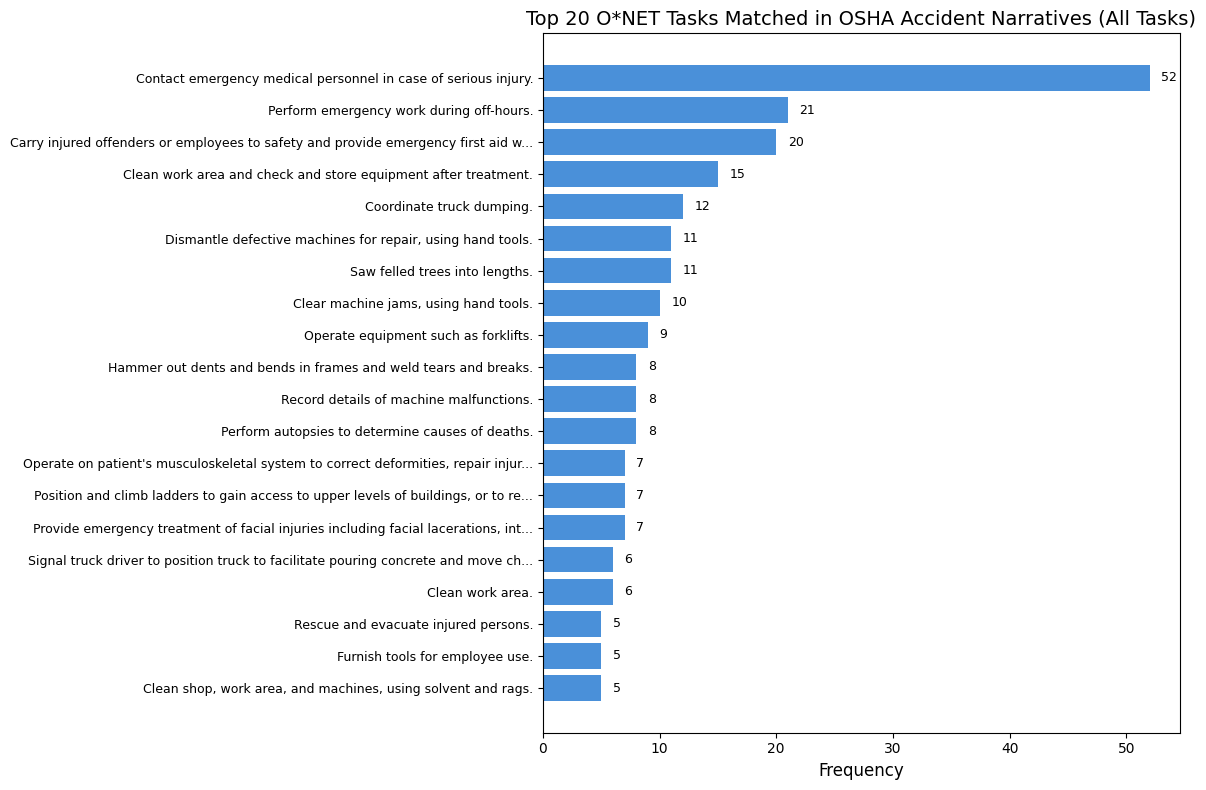

In [ ]:
# Plot top 20 tasks
top20 = task_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20)-1, -1, -1), top20['count'], color='#4A90D9')
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels([d[:80] + '...' if len(d) > 80 else d for d in top20['description']], fontsize=9)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 O*NET Tasks Matched in OSHA Accident Narratives (All Tasks)', fontsize=14)

for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Cleanup: Separating Responder Tasks

Notice that several top-ranked tasks describe **emergency response** activities — contacting medical personnel, carrying injured people to safety, performing emergency work.

These tasks are matched because they are work activities / tasks, and accident narratives describe what happened *after* the injury: EMTs arriving, firefighters responding, etc.

These are real matches, but they reflect the **response to** the accident, not the **work being performed** when the accident occurred.

A workplace safety analysis might want to separate these.

Some domain knowledge helps here - we identify responder tasks by reomoving O\*NET task IDs that contain emergency response-related keywords, and show the before/after comparison.

In [15]:
# Identify emergency responder tasks by examining the top matches
# These are tasks primarily associated with EMTs, firefighters, police, and hospital workers
responder_keywords = [
    'emergency', 'injur',
    'hospital', 'treat wound', 'transport patient',
    'autopsies',
]

def is_responder_task(description):
    desc_lower = description.lower()
    return any(kw in desc_lower for kw in responder_keywords)

task_counts['is_responder'] = task_counts['description'].apply(is_responder_task)
n_responder = task_counts[task_counts['is_responder']]['count'].sum()
n_worker = task_counts[~task_counts['is_responder']]['count'].sum()

print(f'Responder task matches: {n_responder} ({n_responder/(n_responder+n_worker)*100:.1f}%)')
print(f'Worker task matches: {n_worker} ({n_worker/(n_responder+n_worker)*100:.1f}%)')
print(f'\nTop responder tasks identified:')
responder_tasks = task_counts[task_counts['is_responder']].head(10)
for _, row in responder_tasks.iterrows():
    print(f'  [{row["count"]:>4}x] {row["description"]}')

Responder task matches: 150 (16.8%)
Worker task matches: 745 (83.2%)

Top responder tasks identified:
  [  52x] Contact emergency medical personnel in case of serious injury.
  [  21x] Perform emergency work during off-hours.
  [  20x] Carry injured offenders or employees to safety and provide emergency first aid when necessary.
  [   8x] Perform autopsies to determine causes of deaths.
  [   7x] Operate on patient's musculoskeletal system to correct deformities, repair injuries, prevent and treat diseases, or improve or restore patient's functions.
  [   7x] Provide emergency treatment of facial injuries including facial lacerations, intra-oral lacerations, and fractured facial bones.
  [   5x] Rescue and evacuate injured persons.
  [   4x] Transport patients to the hospital or within the hospital.
  [   4x] Inspect playing fields to locate any items that could injure players.
  [   3x] Restrain or aid patients as necessary to prevent injury.


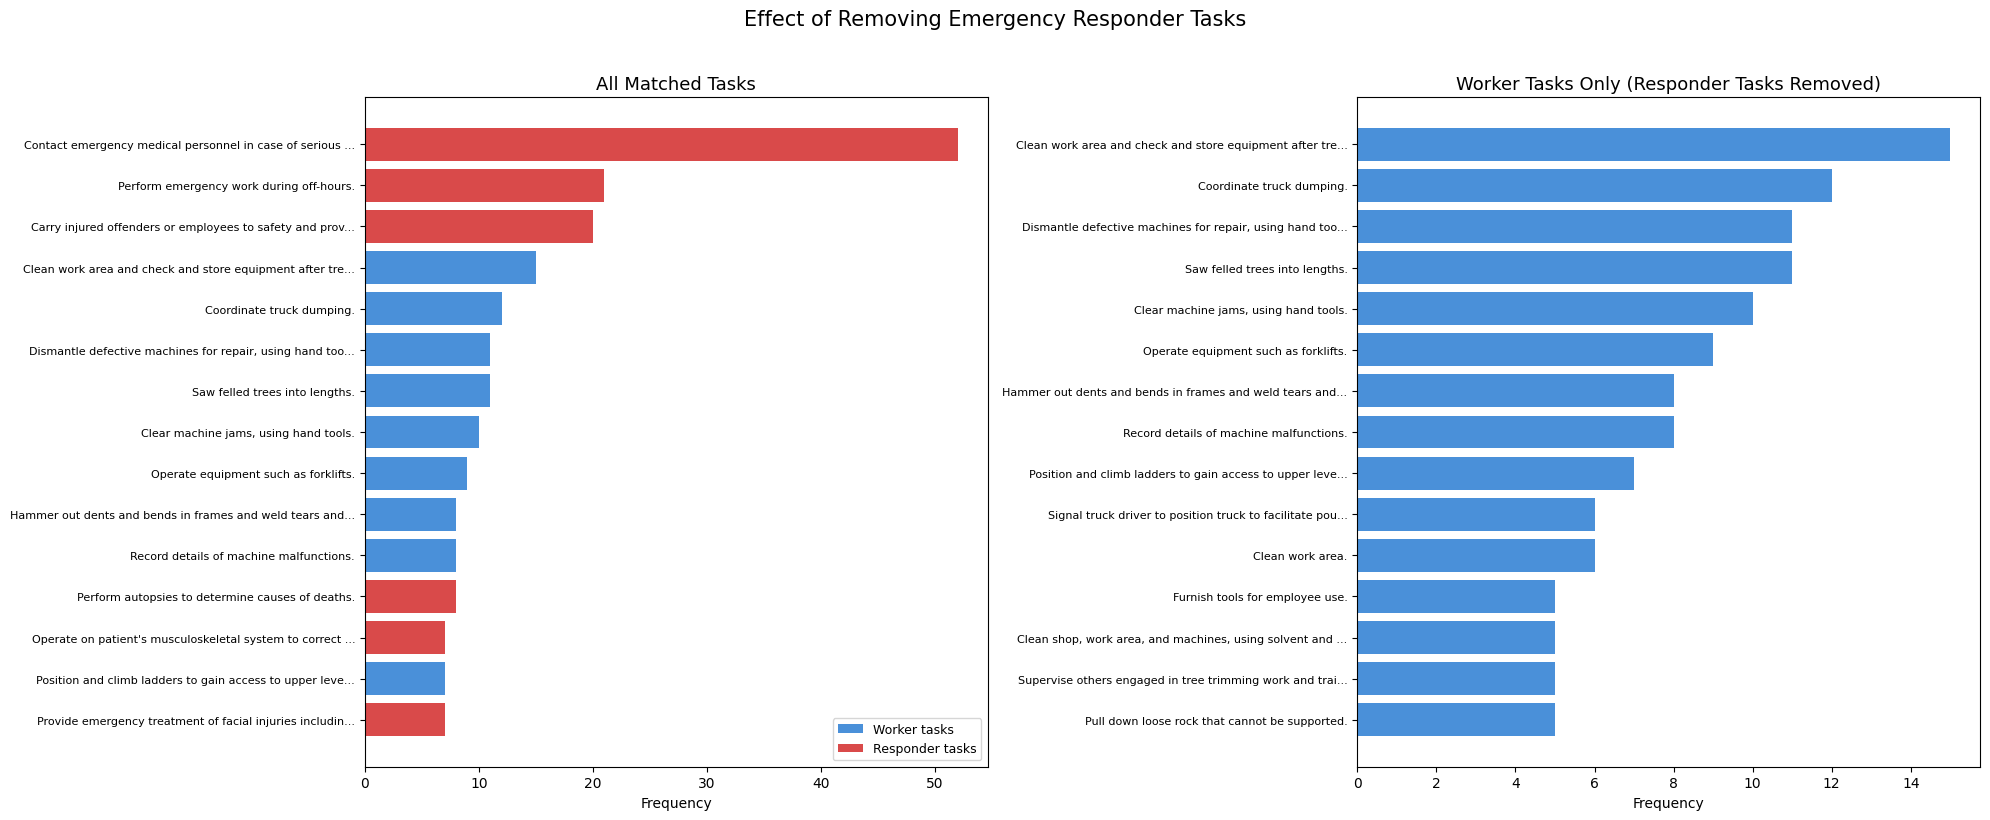

In [16]:
# Side-by-side comparison
worker_tasks = task_counts[~task_counts['is_responder']]
top15_all = task_counts.head(15)
top15_worker = worker_tasks.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left: All tasks
colors_all = ['#D94A4A' if is_responder_task(d) else '#4A90D9' for d in top15_all['description']]
ax1.barh(range(len(top15_all)-1, -1, -1), top15_all['count'], color=colors_all)
ax1.set_yticks(range(len(top15_all)-1, -1, -1))
ax1.set_yticklabels([d[:55] + '...' if len(d) > 55 else d for d in top15_all['description']], fontsize=8)
ax1.set_title('All Matched Tasks', fontsize=13)
ax1.set_xlabel('Frequency')

# Add legend
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor='#4A90D9', label='Worker tasks'),
    Patch(facecolor='#D94A4A', label='Responder tasks'),
], loc='lower right', fontsize=9)

# Right: Worker tasks only
ax2.barh(range(len(top15_worker)-1, -1, -1), top15_worker['count'], color='#4A90D9')
ax2.set_yticks(range(len(top15_worker)-1, -1, -1))
ax2.set_yticklabels([d[:55] + '...' if len(d) > 55 else d for d in top15_worker['description']], fontsize=8)
ax2.set_title('Worker Tasks Only (Responder Tasks Removed)', fontsize=13)
ax2.set_xlabel('Frequency')

plt.suptitle('Effect of Removing Emergency Responder Tasks', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Results: Work Tasks Associated with Workplace Injuries

After removing emergency responder tasks, we see the O\*NET tasks that workers were **performing** when accidents occurred. These represent the work activities most associated with workplace injuries in the OSHA investigation data.

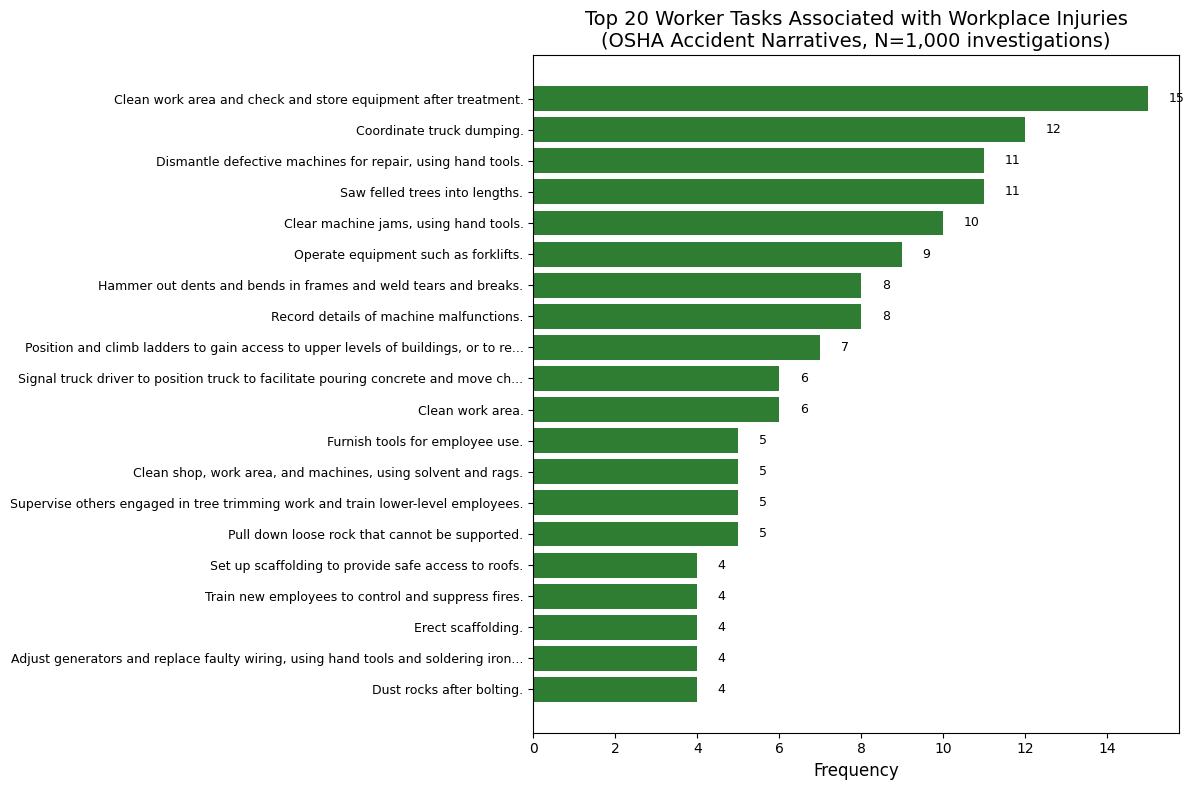

In [17]:
# Final clean visualization
top20_worker = worker_tasks.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20_worker)-1, -1, -1), top20_worker['count'], color='#2E7D32')
ax.set_yticks(range(len(top20_worker)-1, -1, -1))
ax.set_yticklabels([d[:80] + '...' if len(d) > 80 else d for d in top20_worker['description']], fontsize=9)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Worker Tasks Associated with Workplace Injuries\n(OSHA Accident Narratives, N=1,000 investigations)', fontsize=14)

for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# Summary statistics
print('=== Summary ===')
print(f'Accident investigations analyzed: {len(df)}')
print(f'Sentences processed: {len(sentences_df)}')
print(f'Sentences with task matches: {n_with_match} ({n_with_match/len(sentences_df)*100:.1f}%)')
print(f'Total task matches: {len(all_tasks)}')
print(f'Unique O*NET tasks identified: {len(task_counts)}')
print(f'Responder tasks filtered: {n_responder} matches across {len(task_counts[task_counts["is_responder"]])} task types')
print(f'Worker tasks retained: {n_worker} matches across {len(worker_tasks)} task types')

=== Summary ===
Accident investigations analyzed: 1000
Sentences processed: 5014
Sentences with task matches: 892 (17.8%)
Total task matches: 895
Unique O*NET tasks identified: 508
Responder tasks filtered: 150 matches across 24 task types
Worker tasks retained: 745 matches across 484 task types


## Discussion

This demonstration shows three things:

1. **Semantic similarity generalizes.** JAAT's `TaskMatch` was built to identify O\*NET tasks in job postings, but sentence embeddings rely on semantic similarity and generalize to other contexts. `TaskMatch` works on any text that describes work activities — including accident narratives written by OSHA investigators. A thorough analysis in a different corpus would require investigating the appropriate threshold to use.

2. **Domain knowledge matters.** Automated coding tools produce valid matches that will require human interpretation. Emergency responder tasks are genuine semantic matches — the text really does describe those activities — but they describe the *response* to accidents, not the work that caused them. Transparent filtering, as shown above, can address this.

3. **Text to insight, transparently.** The full pipeline from raw narrative text to structured, visualizable output takes under a minute on this sample. Every step is visible and reproducible.

**Learn more:** [JAAT documentation and source code](https://github.com/Job-Ad-Research-at-QSB-LUC/JAAT)